<a href="https://colab.research.google.com/github/AnandKumar-AIML/aiml-demo/blob/main/ANN_model_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [45]:
df = pd.read_csv("powerplant_data.csv")

In [46]:
X= df.drop(["PE"], axis = 1)
y= df["PE"]

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42
)

In [48]:
scaler = StandardScaler()
X_train_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.transform(X_test)

In [49]:
import torch
import torch.nn as nn

In [50]:
X_train_tensor = torch.tensor(X_train_Scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_Scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [51]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [52]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

DeepLearning

In [53]:
class ANN(nn.Module):
  def __init__(self):
    super(ANN, self).__init__()

    self.model = nn.Sequential(
        #1st hidden layer
        nn.Linear(X_train.shape[1], 6),
        nn.ReLU(),

        #2nd hidden layer
        nn.Linear(6, 6),
        nn.ReLU(),

        # output layer
        nn.Linear(6, 1),
    )

  def forward(self, x):
    return self.model(x)

In [54]:
import torch.optim as optim

model = ANN()

c = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [55]:
traninig_loss = []
validation_loss = []
epochs = 100

best_val_loss = float("inf")

for epoch in range(epochs):
  model.train()
  running_loss = 0.0 # total training loss on one epoch

  for xb, yb in train_loader:
    optimizer.zero_grad() #reset gradients

    outputs = model(xb) #predicted outputs for this batch
    loss = c(outputs, yb)# compute loss
    loss.backward() #back propogation, compute gradients
    optimizer.step() #params update

    running_loss += loss.item() # loss is a tensor value => python float

  epochs_training_loss = running_loss/len(train_loader)
  traninig_loss.append(epochs_training_loss)


# validation
  model.eval()
  running_val_loss = 0.0
  with torch.no_grad():
    for xb, yb in test_loader:
      outputs = model(xb)
      loss = c(outputs, yb)
      running_val_loss += loss.item()
    epochs_val_loss = running_val_loss/len(test_loader)
    validation_loss.append(epochs_val_loss)

    print(f"Epoch {epoch+1}/{epochs}, Training Loss: {epochs_training_loss:.4f}, Validation Loss: {epochs_val_loss:.4f}")

    if epochs_val_loss < best_val_loss:
      best_val_loss = epochs_val_loss
      torch.save(model.state_dict(), "best_model.pt")

Epoch 1/100, Training Loss: 205249.2639, Validation Loss: 202242.0221
Epoch 2/100, Training Loss: 193228.2228, Validation Loss: 179147.9721
Epoch 3/100, Training Loss: 154516.4352, Validation Loss: 126961.8220
Epoch 4/100, Training Loss: 99298.2495, Validation Loss: 76246.3242
Epoch 5/100, Training Loss: 60600.3209, Validation Loss: 48492.6601
Epoch 6/100, Training Loss: 39019.1594, Validation Loss: 30739.7259
Epoch 7/100, Training Loss: 24288.3310, Validation Loss: 18771.7598
Epoch 8/100, Training Loss: 15324.3883, Validation Loss: 12238.5054
Epoch 9/100, Training Loss: 10541.3589, Validation Loss: 8679.3172
Epoch 10/100, Training Loss: 7575.2430, Validation Loss: 6168.8869
Epoch 11/100, Training Loss: 5361.0060, Validation Loss: 4349.3836
Epoch 12/100, Training Loss: 3788.1005, Validation Loss: 3157.4697
Epoch 13/100, Training Loss: 2796.7362, Validation Loss: 2422.9722
Epoch 14/100, Training Loss: 2177.7975, Validation Loss: 1943.2925
Epoch 15/100, Training Loss: 1763.4828, Validati

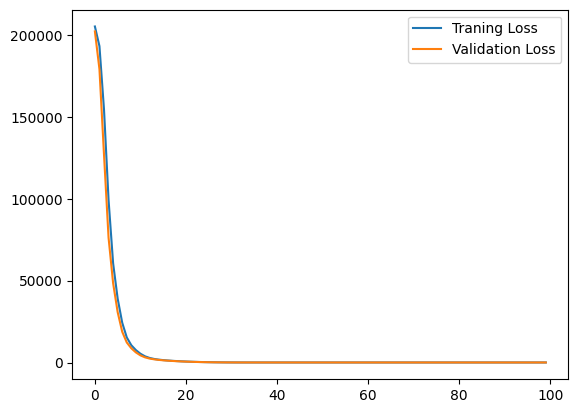

In [56]:
import matplotlib.pyplot as plt
plt.plot(traninig_loss, label = "Traning Loss")
plt.plot(validation_loss, label = "Validation Loss")
plt.legend()

In [57]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [60]:
#Evaluation
model.eval()
with torch.no_grad():
  train_pred = model(X_train_tensor)
  test_pred = model(X_test_tensor)

  train_mse_loss = c(train_pred, y_train_tensor)
  test_mse_loss = c(test_pred, y_test_tensor)
  print("Training Loss:", train_mse_loss.item())
  print("Testing Loss:", test_mse_loss.item())

Training Loss: 21.124561309814453
Testing Loss: 19.56436538696289


In [61]:
from sklearn.metrics import r2_score
print("R2_Score:", r2_score(y_test, test_pred))

R2_Score: 0.9316275925121382


In [69]:
#compare predicted value with actual value
predicted_value = pd.DataFrame(test_pred.numpy(), columns = ["Predicted Value"])
actual_value = pd.DataFrame(y_test.values, columns = ["Actual Value"])
pd.concat([predicted_value, actual_value], axis = 1)

,Predicted Value,Actual Value
0,435.505402,433.27
1,437.169464,438.16
2,461.329742,458.42
3,476.297028,480.82
4,435.530731,441.41
...,...,...
1909,451.475983,456.70
1910,431.854553,438.04
1911,467.831726,467.80
1912,431.313995,437.14
